# Using a Normalizing Flow to generate image embeddings
## A simple demo of RealNVP in pure PyTorch
### Authors: Jary Pomponi & Simone Scardapane

# Introduction

In this notebook we want to show how a Normalizing Flow (NF) can be used to learn a prior over the embeddings of an autoencoder, allowing fast sampling of real looking images.

### A (very brief) primer on NFs

A NF is a method that allows the construction of flexible posterior distributions starting from a simpler one defined by a collection of continuous random variables. Given a vector $\mathbf{x}$, we want to express it as transformations $T(\cdot)$ from a real vector $\mathbf{u}$ sampled from a prior $p(\mathbf{u})$: 

$$\mathbf{x} = T(\mathbf{u})$$

The key property of the transformation $T(\cdot)$ is that it must be invertible and both the transformation and its inverse must be differentiable. Under these conditions, $p(\mathbf{x})$ is well defined and can be obtained via the change of variables: 

$$p(\mathbf{x}) = p(\mathbf{u}) \vert \text{det}J_T(\mathbf{u}) \vert^{-1} \, \, \text{with} \, \, \mathbf{u} = T^{-1}(\mathbf{x})$$

Another property of these transformations is that they be composed: 

$$ \mathbf{x} = T_k \circ T_{k-1} \dots \circ T_1(\mathbf{u}) $$
$$ \mathbf{u} = (T_k \circ T_{k-1} \dots \circ T_1)^{-1}(\mathbf{x}) = (T_1 \circ T_{2} \dots \circ T_k)(\mathbf{x}) $$

and the Jacobians of the resulting transformation are simply the product of the components' Jacobians.

Using these properties we can build a complex transofrmation which is a combination of simpler ones, leading to a more complex distribution $\mathbf{x}$, provided the networks can be inverted and the determinant of the base Jacobian are tractable.

### What we do in this notebook

In this notebook we use a model proposed in [RealNVP](https://arxiv.org/abs/1605.08803). Each transformation can either be an affine coupling layer (see the code below), a permutation, or a batch normalization layer. For more informations on each layer we refer to the original paper or the other references in the README file.

To generate samples from the MNIST dataset and make the problem tractable, we train the model on embeddings generated by a separate autoencoder instead of the raw pixels.

# Code

In [1]:
import torch
from torch import nn
import rnvp
import numpy as np
from torchvision import datasets, transforms
import itertools
import matplotlib.pyplot as plt

## Hyper-parameters

In [2]:
EMBEDDING_DIM = 20 # The dimension of the embeddings
FLOW_N = 9 # Number of affine coupling layers
RNVP_TOPOLOGY = [200] # Size of the hidden layers in each coupling layer
AE_EPOCHS = 10 # Epochs for training the autoencoder
NF_EPOCHS = 20 # Epochs for training the normalizing flow
SEED = 0 # Seed of the random number generator
BATCH_SIZE = 100 # Batch size

In [3]:
# Set the random seeds
torch.manual_seed(0)
np.random.seed(0)

# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### Autoencoder definition

In [5]:
class AutoEncoder(nn.Module):
    """
    A simple autoencoder for images. 
    self.linear1 generates the intermediate embeddings that we use for the normalizing flow.
    """
    def __init__(self):
        super().__init__()
        
        # Encoding layers
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, stride=2, kernel_size=3, bias=False, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, stride=2, kernel_size=3, bias=False, padding=1)
        self.linear1 = nn.Linear(in_features=3136, out_features=EMBEDDING_DIM)
        
        # Decoding layers
        self.linear2 = nn.Linear(in_features=EMBEDDING_DIM, out_features=3136)
        self.convt1 = nn.ConvTranspose2d(in_channels=64, out_channels=32, stride=2, kernel_size=3, padding=1, output_padding=1)
        self.convt2 = nn.ConvTranspose2d(in_channels=32, out_channels=1, stride=2, kernel_size=3, padding=1, output_padding=1)


    def forward(self, x):
        
        emb = self.encoder(x)
        _x = self.decoder(emb)
        
        return _x, emb
    
    def decoder(self, emb):

        _x = torch.relu(self.linear2(emb))
        _x = _x.view(-1, 64, 7, 7)
        _x = torch.relu(self.convt1(_x))
        _x = self.convt2(_x)
        
        return _x
    
    def encoder(self, x):
        _x = torch.relu(self.conv1(x))
        _x = torch.relu(self.conv2(_x))
        sh = _x.shape

        _x = torch.relu(torch.flatten(_x, 1))
        
        emb = self.linear1(_x)
        
        return emb

### Autoencoder training on MNIST

In [6]:
# Load the dataset
train_set = datasets.MNIST('../MNIST_data', train=True, download=False,
                            transform=transforms.Compose([
                                transforms.ToTensor(),
                                # transforms.Normalize((0.5,), (0.5,))
                            ]))
train_loader = torch.utils.data.DataLoader(train_set, BATCH_SIZE)

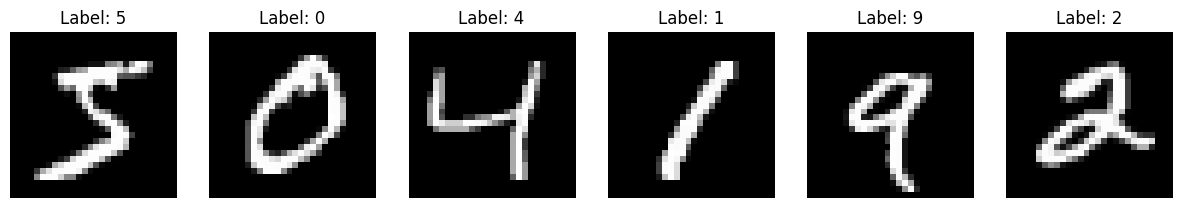

In [7]:
# Display images from the train_set
import matplotlib.pyplot as plt

# Get a batch of images and labels
images, labels = next(iter(train_loader))

# Plot the images
fig, axes = plt.subplots(1, 6, figsize=(15, 15))
for i in range(6):
    ax = axes[i]
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f'Label: {labels[i].item()}')
    ax.axis('off')

plt.show()

In [8]:
# We use a binary cross-entropy loss for the reconstruction error
loss_f = nn.BCELoss()

# Build the autoencoder
autoencoder = AutoEncoder()
autoencoder = autoencoder.to(device)

optimizer = torch.optim.Adam(itertools.chain(autoencoder.parameters()),
                             lr=1e-3, weight_decay=1e-5)

In [ ]:
from tqdm import tqdm
for i in range(AE_EPOCHS):
    print('Epoch #{}'.format(i+1))

    losses = []
    for batch_idx, data in enumerate(tqdm(train_loader)):

        x, _ = data
        x = x.to(device)

        # Run the autoencoder
        _x, emb = autoencoder(x)
        _x = torch.sigmoid(_x)

        # Compute loss
        rec_loss = loss_f(_x, x)

        autoencoder.zero_grad()
        rec_loss.backward()
        optimizer.step()
        
torch.save(autoencoder.state_dict(), 'autoencoder_nf.pth')

In [9]:
# Load the autoencoder
autoencoder.load_state_dict(torch.load('autoencoder_nf.pth'))

C:\Users\lenovo\AppData\Local\Temp\ipykernel_10524\1194205898.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  autoencoder.load_state_dict(torch.load('autoencoder_nf.pth'

<All keys matched successfully>

### Creating a new dataset containing the embeddings and the associated labels

In [10]:
# We replace the original x with the corresponding embedding from the trained autoencoder
embs = []
for batch_idx, data in enumerate(train_loader):

    with torch.no_grad():
        x, y = data

        x = x.to(device)

        _, emb = autoencoder(x)
        for i in range(len(emb)):
            embs.append((emb[i], y[i]))

In [11]:
embs_loader = torch.utils.data.DataLoader(embs, BATCH_SIZE)

### Normalizing Flow training

In [12]:
# See the file realmvp.py for the full definition
nf_model = rnvp.LinearRNVP(input_dim=EMBEDDING_DIM, coupling_topology=RNVP_TOPOLOGY, flow_n=FLOW_N, batch_norm=True,
                      mask_type='odds', conditioning_size=10, use_permutation=True, single_function=True)
nf_model = nf_model.to(device)

optimizer1 = torch.optim.Adam(itertools.chain(nf_model.parameters()), lr=1e-4, weight_decay=1e-5)

In [ ]:
from tqdm import tqdm
nf_model.train()
for i in range(NF_EPOCHS):
    print('Epoch #{}'.format(i+1))

    losses = []
    for batch_idx, data in enumerate(tqdm(embs_loader)):

        emb, y = data
        emb = emb.to(device)
        y = y.to(device)
        y = torch.nn.functional.one_hot(y, 10).to(device).float()
        
        # Get the inverse transformation and the corresponding log determinant of the Jacobian
        u, log_det = nf_model.forward(emb, y=y) 

        # Train via maximum likelihood
        prior_logprob = nf_model.logprob(u)
        log_prob = -torch.mean(prior_logprob.sum(1) + log_det)

        nf_model.zero_grad()

        log_prob.backward()

        optimizer1.step()

torch.save(nf_model.state_dict(), 'nf_model.pth')

In [13]:
nf_model.load_state_dict(torch.load('nf_model.pth'))

C:\Users\lenovo\AppData\Local\Temp\ipykernel_10524\3775382929.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  nf_model.load_state_dict(torch.load('nf_model.pth'))


<All keys matched successfully>

### Evaluating the NF

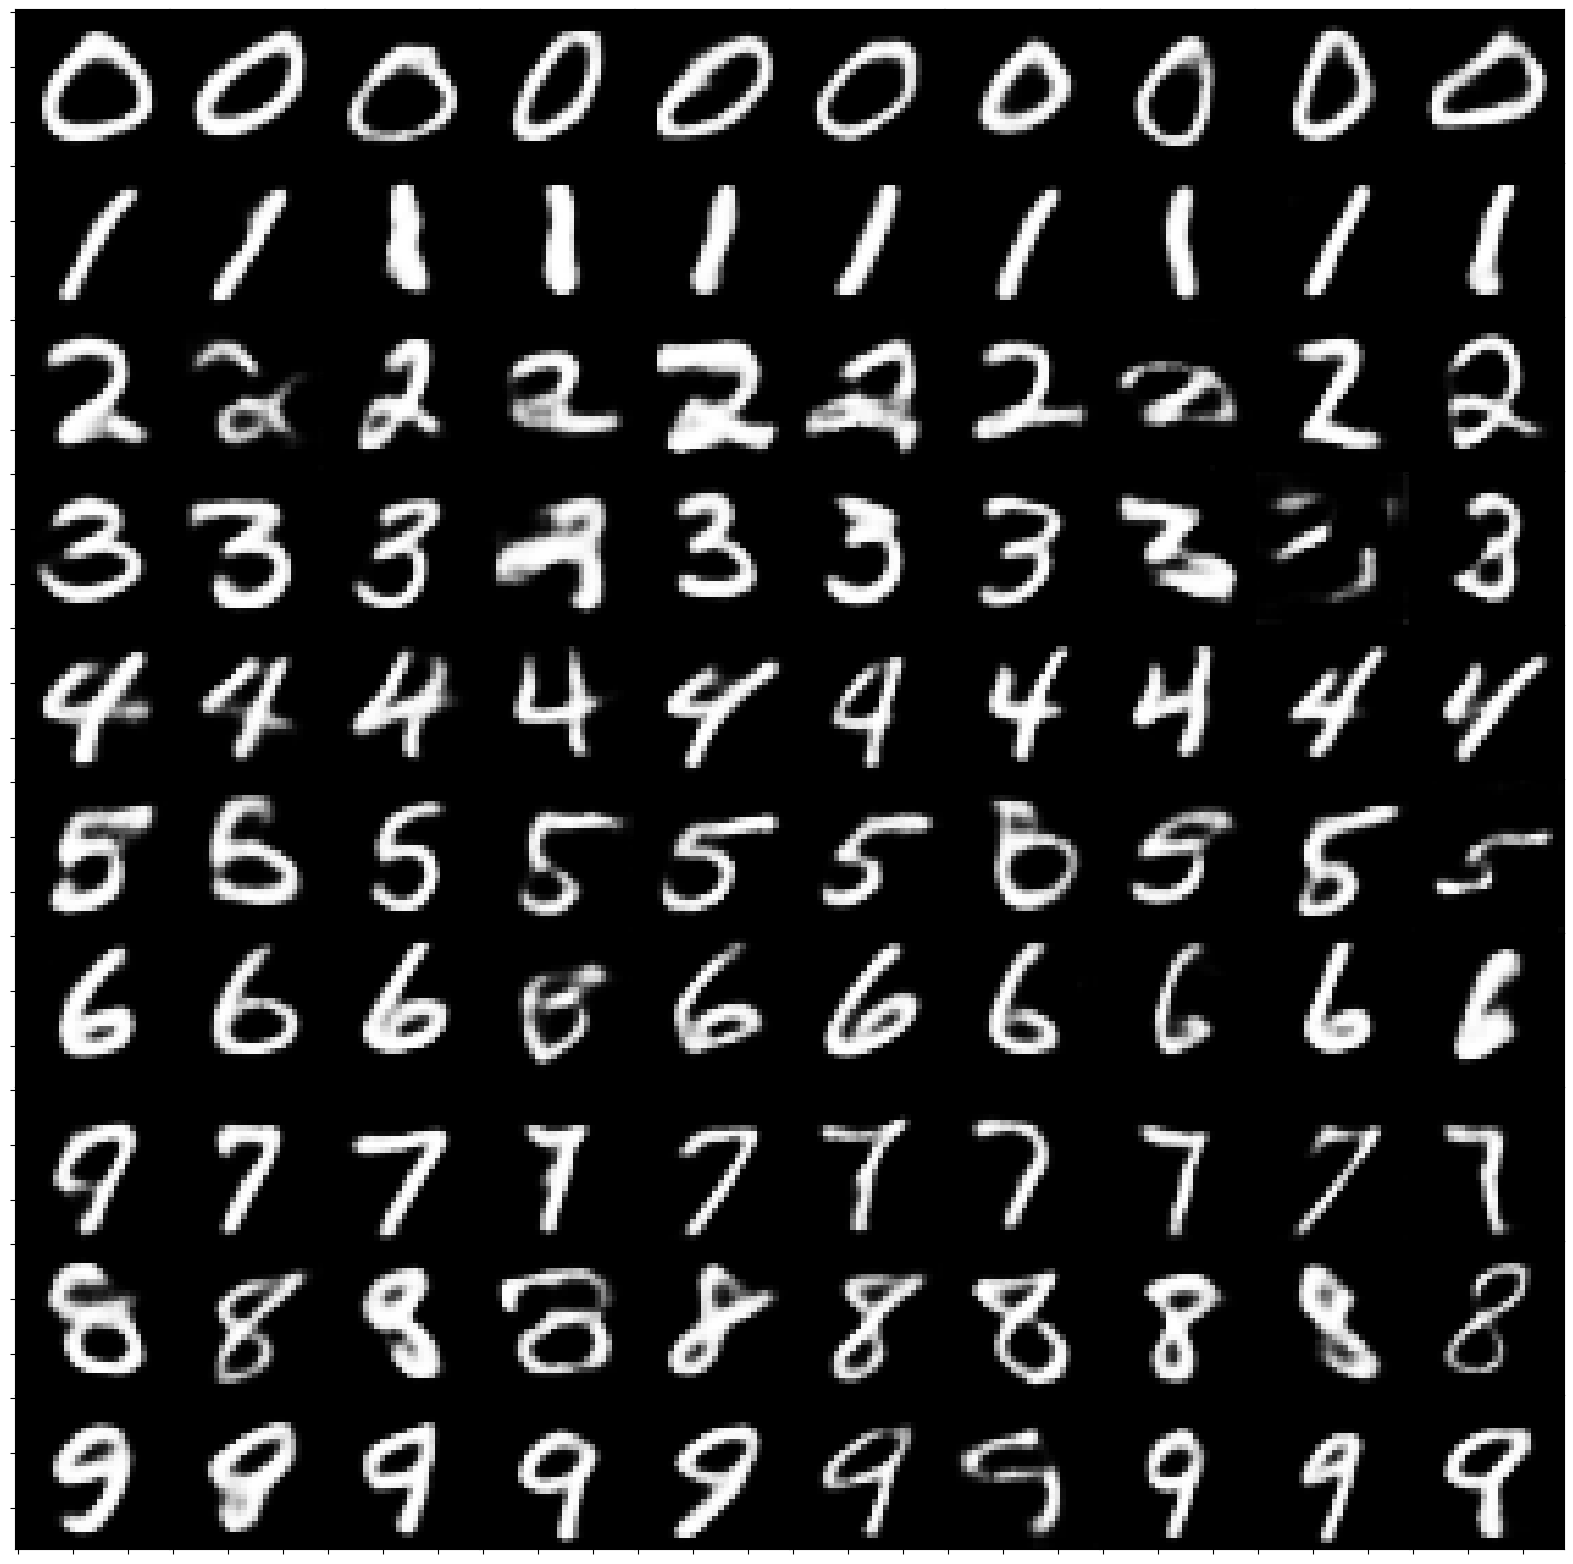

In [14]:
sample_n = 10
f, axs = plt.subplots(nrows=10, ncols=sample_n, figsize=(20, 20))

nf_model.eval()
with torch.no_grad():
    for j in range(10):

        y = torch.nn.functional.one_hot(torch.tensor([j]*sample_n), 10).to(device).float()
        emb, d = nf_model.sample(sample_n, y=y, return_logdet=True)
        z = autoencoder.decoder(emb)

        d_sorted = d.sort(0)[1].flip(0)
        z = z[d_sorted]
        z = torch.sigmoid(z).cpu()
        
        for i in range(sample_n):
            axs[j][i].imshow(z[i].reshape(28, 28), cmap='gray')

for ax in axs:
    for a in ax:
        a.set_xticklabels([])
        a.set_yticklabels([])
        a.set_aspect('equal')

f.subplots_adjust(wspace=0, hspace=0)
plt.show()
plt.close('all')

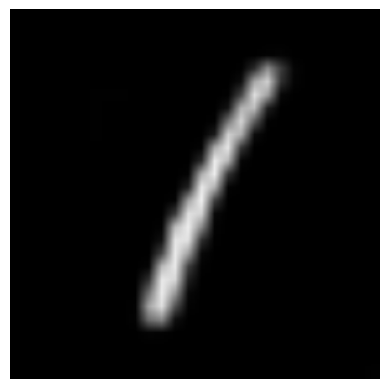

In [15]:
# Generate a random image
nf_model.eval()
with torch.no_grad():
    y = torch.nn.functional.one_hot(torch.randint(0, 10, (1,)), 10).to(device).float()
    emb, _ = nf_model.sample(1, y=y, return_logdet=True)
    z = autoencoder.decoder(emb)
    z = torch.sigmoid(z).cpu().numpy().squeeze()

# Apply the transformation
transform = transforms.Compose([
    transforms.Grayscale(3),  # Convert image from 1 channel to 3 channels
    transforms.Resize((299, 299)),  # Resize image for InceptionV3
    transforms.ToTensor()
])

# Convert the numpy image to a PIL image
z_pil = transforms.ToPILImage()(z)

# Apply the transformation
z_transformed = transform(z_pil)

# Display the transformed image
plt.imshow(z_transformed.permute(1, 2, 0))
plt.axis('off')
plt.show()

In [16]:
transform = transforms.Compose([
        transforms.Grayscale(3),  # Chuyển từ 1 channel sang 3 channels
        transforms.Resize((299, 299)),  # Resize về 299x299
        transforms.ToTensor(),  # Chuyển đổi sang tensor
    ])

In [17]:
from torch.utils.data import Subset

# Tải toàn bộ test set của MNIST
test_set = datasets.MNIST('../MNIST_data', train=False, download=False, transform=transform)

# Chọn 1000 ảnh đầu tiên từ test_set
subset_indices = list(range(1000))
test_subset = Subset(test_set, subset_indices)

# Tạo DataLoader từ phần subset này
test_loader = torch.utils.data.DataLoader(test_subset, BATCH_SIZE, shuffle=False)

In [18]:
def generate_random_images(n=1000, transform=transform):
    nf_model.eval()
    images = []
    
    with torch.no_grad():
        for _ in range(n):
            y = torch.nn.functional.one_hot(torch.randint(0, 10, (1,)), 10).to(device).float()
            emb, _ = nf_model.sample(1, y=y, return_logdet=True)
            z = autoencoder.decoder(emb)
            z = torch.sigmoid(z).cpu().numpy().squeeze()
            
            # Convert numpy array to PIL Image for transformations
            pil_image = transforms.functional.to_pil_image(z)
            transformed_image = transform(pil_image)
            images.append(transformed_image)
    
    # Stack the images into a tensor
    return torch.stack(images)

# Generate 1000 random images với transform
generated_images = generate_random_images(1000, transform)


In [19]:
test_images = []
test_labels = []
for images, labels in test_loader:
    test_images.append(images)
    test_labels.append(labels)

# Ghép các ảnh lại thành một tensor duy nhất
test_images = torch.cat(test_images)[:1000]

In [20]:
test_images.shape, generated_images.shape

(torch.Size([1000, 3, 299, 299]), torch.Size([1000, 3, 299, 299]))

In [21]:
np.unique(test_labels, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int64),
 array([ 85, 126, 116, 107, 110,  87,  87,  99,  89,  94], dtype=int64))

In [22]:
from torchmetrics.image.fid import FrechetInceptionDistance

fid = FrechetInceptionDistance(feature=2048)

test_images_fid = (test_images * 255).to(torch.uint8)
fid.update(test_images_fid, real=True)

# Cập nhật ảnh được sinh ra
generated_images_fid = (generated_images * 255).to(torch.uint8)
fid.update(generated_images_fid, real=False)

# Tính FID
fid_score = fid.compute()
print(f"FID Score: {fid_score}")

FID Score: 30.113666534423828
